**Retail Sales Forecasting Project**

**Author:** Akshay Bhujbal

**Project Type:** Time Series / Machine Learning / Deep Learning Portfolio Project

**Project Overview**

This project demonstrates a **Retail Sales Forecasting system** using:

- **HistGradientBoostingRegressor (ML)** – a modern, efficient gradient boosting model
- **LSTM (Deep Learning)** – captures temporal dependencies in sales data
The project allows users to:

1. Analyze historical weekly sales trends for different stores and departments. 
2. Forecast future weekly sales using ML and Deep Learning models.
3. Visualize actual vs predicted sales in an interactive dashboard.
4. Explore the impact of store type, promotions, holidays, and other features on sales.

**Datasets Used:**

- [Retail Dataset on Kaggle](https://www.kaggle.com/datasets/manjeetsingh/retaildataset)

- ```sales.csv``` → Historical weekly sales (```Store```, ```Dept```, ```Date```, ```Weekly_Sales```)
- ```features.csv``` → External factors (```Store```, ```Date```, ```Temperature```, ```Fuel_Price```, ```Holiday_Flag```, ```Promotion```)
- ```stores.csv``` → Store metadata (```Store```, ```Type```, ```Size```)

The model predicts **weekly sales per store and department** based on historical sales, store features, and external factors.

# Import Libraries

We start by importing all necessary libraries.

- ```pandas```, ```numpy``` → for data manipulation and analysis
- ```matplotlib```, ```seaborn``` → for plots and insights
- ```HistGradientBoostingRegressor``` → faster alternative to Random Forest for large datasets
- ```LSTM``` → captures temporal trends in time series data

In [49]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Load Datasets

- Load all three datasets and check the first few rows to understand structure and features.
- Convert Date to datetime:

In [2]:
# Load CSVs
sales = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\TS\data\Sales.csv")
features = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\TS\data\Features.csv")
stores = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\TS\data\Stores.csv")

# Quick look
print(sales.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False


In [3]:
# Quick look

print(features.head())

   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05/02/2010        42.31       2.572        NaN        NaN   
1      1  12/02/2010        38.51       2.548        NaN        NaN   
2      1  19/02/2010        39.93       2.514        NaN        NaN   
3      1  26/02/2010        46.63       2.561        NaN        NaN   
4      1  05/03/2010        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  


In [4]:
# Quick look
print(stores.head())

   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875


In [5]:
# Convert Date to datetime:
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

# Merge Datasets

- Combine sales, features, and store metadata to have all information in one dataset.
- Ensures ML and deep learning models have contextual features (holidays, promotions, store type).

In [6]:
# Merge datasets to create a single dataframe
df = sales.merge(features, on=['Store','Date'], how='left')
df = df.merge(stores, on='Store', how='left')
print(df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment  IsHoliday_y Type    Size  
0         8.106        False    A  1

In [7]:
# Use holiday from sales
df['IsHoliday'] = df['IsHoliday_x']

In [8]:
# Drop redundant holiday columns
df.drop(['IsHoliday_x','IsHoliday_y'], axis=1, inplace=True)

print(df.head())

   Store  Dept       Date  Weekly_Sales  Temperature  Fuel_Price  MarkDown1  \
0      1     1 2010-02-05      24924.50        42.31       2.572        NaN   
1      1     1 2010-02-12      46039.49        38.51       2.548        NaN   
2      1     1 2010-02-19      41595.55        39.93       2.514        NaN   
3      1     1 2010-02-26      19403.54        46.63       2.561        NaN   
4      1     1 2010-03-05      21827.90        46.50       2.625        NaN   

   MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment Type  \
0        NaN        NaN        NaN        NaN  211.096358         8.106    A   
1        NaN        NaN        NaN        NaN  211.242170         8.106    A   
2        NaN        NaN        NaN        NaN  211.289143         8.106    A   
3        NaN        NaN        NaN        NaN  211.319643         8.106    A   
4        NaN        NaN        NaN        NaN  211.350143         8.106    A   

     Size  IsHoliday  
0  151315      False 

# Exploratory Data Analysis (EDA)

- Visualizations help identify trends, seasonality, outliers, and feature correlations.
- Shows which stores or external factors impact sales the most.

## Check missing values

In [9]:
print(df.isnull().sum())

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
IsHoliday            0
dtype: int64


## handle these missing values

- Replace NaNs with 0 (common for MarkDowns because no markdown means 0 discount)

In [10]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

## Sales over time

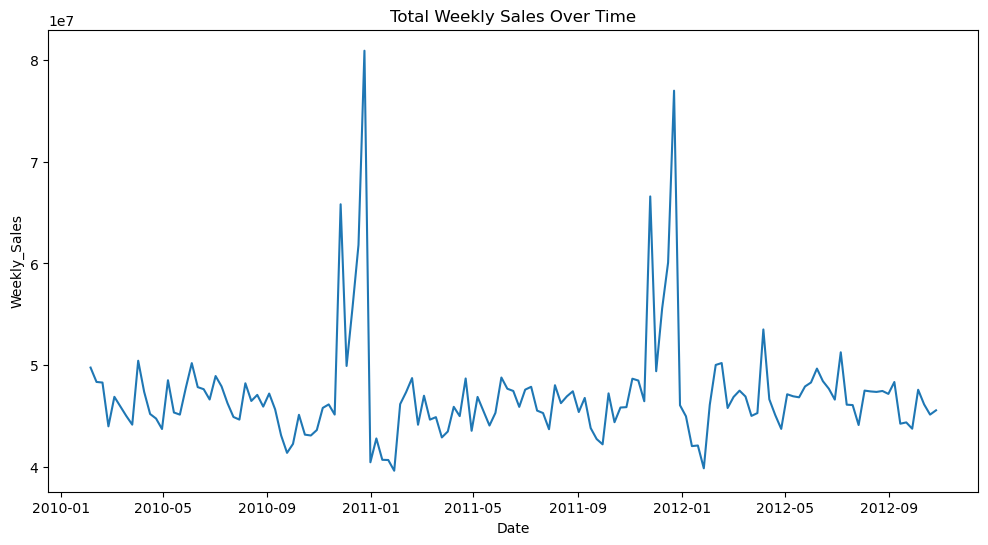

In [11]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df.groupby('Date')['Weekly_Sales'].sum())
plt.title("Total Weekly Sales Over Time")
plt.show()

## Sales by store type

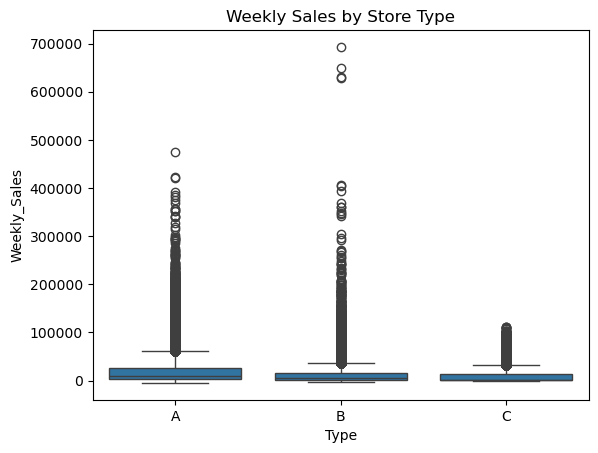

In [12]:
sns.boxplot(x='Type', y='Weekly_Sales', data=df)
plt.title("Weekly Sales by Store Type")
plt.show()

## Correlation between numeric features

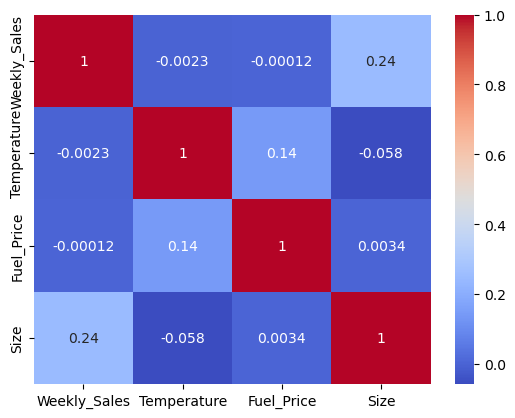

In [13]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'Size']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# Feature Engineering

- Lag features allow models to capture temporal dependencies.
- Date features help capture seasonal trends.
- External factors like promotions and holidays impact sales.

## Date features

In [14]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek

## Lag features (sales from previous weeks)

- Lag features capture **temporal dependencies**.
- Date features capture **seasonal trends.**

In [15]:
df['Lag_1'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['Lag_2'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)
df['Lag_1'] = df['Lag_1'].fillna(0)
df['Lag_2'] = df['Lag_2'].fillna(0)

# Data Preprocessing

## Encode categorical features

In [16]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Feature Scaling for LSTM

In [50]:
feature_cols = ['Temperature','Fuel_Price','MarkDown1','MarkDown2','MarkDown3',
                'MarkDown4','MarkDown5','CPI','Unemployment','Type','Size',
                'IsHoliday','Lag_1','Lag_2']

# Scale features
scaler = MinMaxScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Scale target
target_scaler = MinMaxScaler()
df['Weekly_Sales_Scaled'] = target_scaler.fit_transform(df[['Weekly_Sales']])

# Machine Learning Model – HistGradientBoostingRegressor

- Faster than Random Forest on large datasets
- Handles numeric and categorical features efficiently
- RMSE evaluates prediction accuracy

In [51]:
X = df.drop(['Weekly_Sales', 'Weekly_Sales_Scaled', 'Date'], axis=1)
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize model
hgb = HistGradientBoostingRegressor(max_iter=100, random_state=42)
hgb.fit(X_train, y_train)

# Predictions & Evaluation
y_pred_hgb = hgb.predict(X_test)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
print(f"HistGradientBoosting RMSE: {rmse_hgb:.2f}")

HistGradientBoosting RMSE: 3983.38


# Deep Learning Model – LSTM

## Create sequences for LSTM

In [52]:
def create_sequences_lstm(df_store, features, target, seq_length=4):
    X_seq, y_seq = [], []
    data = df_store[features + [target]].values
    for i in range(len(data)-seq_length):
        X_seq.append(data[i:i+seq_length, :-1])
        y_seq.append(data[i+seq_length, -1])
    return np.array(X_seq), np.array(y_seq)

# Example: Store 1, Dept 1
df_sd = df[(df['Store']==1) & (df['Dept']==1)].sort_values('Date')
train_size = int(len(df_sd)*0.8)
df_train = df_sd.iloc[:train_size]
df_val = df_sd.iloc[train_size:]

seq_length = 4
X_train_seq, y_train_seq = create_sequences_lstm(df_train, feature_cols, 'Weekly_Sales_Scaled', seq_length)
X_val_seq, y_val_seq = create_sequences_lstm(df_val, feature_cols, 'Weekly_Sales_Scaled', seq_length)

## Build & Train LSTM

In [53]:
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - loss: 0.0022 - val_loss: 7.3719e-04
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.8061e-04 - val_loss: 5.6112e-05
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.5333e-04 - val_loss: 1.0421e-04
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.1306e-04 - val_loss: 1.0714e-04
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.6813e-04 - val_loss: 3.1472e-05
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.8636e-04 - val_loss: 2.2288e-05
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.7421e-04 - val_loss: 1.0406e-04
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.4411e-04 - val_loss: 6.2843e-05
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.9225e-04 - val_loss: 9.7093e-05
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.1381e-04 - val_loss: 1.6063e-05
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.

# Evaluate LSTM

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
Validation RMSE: 2797.85
Validation MAE: 2458.98


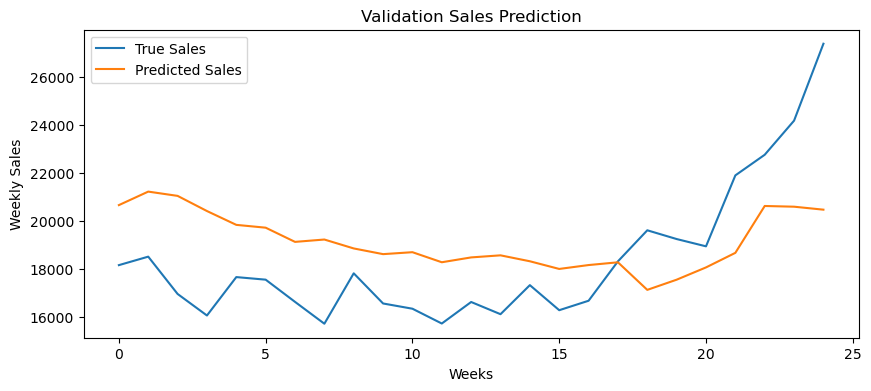

In [54]:
y_pred_scaled = model.predict(X_val_seq)
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1,1))
y_true = target_scaler.inverse_transform(y_val_seq.reshape(-1,1))

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation MAE: {mae:.2f}")

# Plot predictions
plt.figure(figsize=(10,4))
plt.plot(y_true, label='True Sales')
plt.plot(y_pred, label='Predicted Sales')
plt.title("Validation Sales Prediction")
plt.xlabel("Weeks")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

# Save the Trained Models
We have **two models:**

1. **HistGradientBoostingRegressor (ML)**
2. **LSTM (Deep Learning)**

We’ll save them so we can load them in Streamlit later.

- ```hgb_model.pkl``` → ML model
- ```feature_scaler.pkl``` & ```target_scaler.pkl``` → for scaling inputs & outputs
- ```lstm_model.h5``` → Deep learning model

In [63]:
# ML Model
import joblib

# Save the ML model
joblib.dump(hgb, "hgb_model.pkl", protocol=4)

# Save scalers
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")


# Deep Learning LSTM Model
model.save("lstm_model.h5")  # Saves the LSTM model

# Retail Sales Forecasting App Guide
## app.py file
Create a new Python file called app.py and add the following code:
```python 
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt

# ----------------------------
# Page config and dark theme
# ----------------------------
st.set_page_config(page_title="Retail Sales Forecasting", layout="wide", page_icon="📊")

st.markdown("""
    <style>
    body {background-color: #0e1117; color: #ffffff;}
    .stButton>button {background-color: #1f77b4; color: white;}
    .stNumberInput>div>input {background-color: #1e1e1e; color: white;}
    .stSelectbox>div>div {background-color: #1e1e1e; color: white;}
    </style>
    """, unsafe_allow_html=True)

st.title("📊 Retail Sales Forecasting Dashboard")

# ----------------------------
# Load models and scalers
# ----------------------------
hgb = joblib.load("hgb_model.pkl")
scaler = joblib.load("feature_scaler.pkl")
target_scaler = joblib.load("target_scaler.pkl")
lstm_model = load_model("lstm_model.h5", compile=False)

# ----------------------------
# User Inputs (3 Columns × 5 Rows)
# ----------------------------
col1, col2, col3 = st.columns(3)

with col1:
    store = st.number_input("Store Number", min_value=1)
    temperature = st.number_input("Temperature")
    markdown1 = st.number_input("MarkDown1")
    markdown4 = st.number_input("MarkDown4")
    cpi = st.number_input("CPI")

with col2:
    dept = st.number_input("Department Number", min_value=1)
    fuel_price = st.number_input("Fuel Price")
    markdown2 = st.number_input("MarkDown2")
    markdown5 = st.number_input("MarkDown5")
    unemployment = st.number_input("Unemployment")

with col3:
    markdown3 = st.number_input("MarkDown3")
    store_type = st.selectbox("Store Type", ["A","B","C"])
    size = st.number_input("Store Size")
    is_holiday = st.checkbox("Is Holiday")
    lag1 = st.number_input("Lag 1 Sales")
    lag2 = st.number_input("Lag 2 Sales")  # 6th field in col3, okay for last row

# ----------------------------
# Predict button
# ----------------------------
if st.button("Predict Sales"):
    
    # Encode store type
    le = LabelEncoder()
    le.fit(["A","B","C"])
    store_type_encoded = le.transform([store_type])[0]
    
    # Prepare input DataFrame
    input_df = pd.DataFrame([[temperature, fuel_price, markdown1, markdown2, markdown3, markdown4,
                              markdown5, cpi, unemployment, store_type_encoded, size, is_holiday,
                              lag1, lag2]],
                            columns=['Temperature','Fuel_Price','MarkDown1','MarkDown2','MarkDown3',
                                     'MarkDown4','MarkDown5','CPI','Unemployment','Type','Size',
                                     'IsHoliday','Lag_1','Lag_2'])
    
    # Scale features
    input_scaled = scaler.transform(input_df)
    
    # ML Prediction (Current)
    ml_scaled_pred = hgb.predict(input_scaled)
    ml_pred = target_scaler.inverse_transform(ml_scaled_pred.reshape(-1,1))[0][0]
    
    # LSTM Prediction (Future)
    input_seq = input_scaled.reshape((1, input_scaled.shape[1], 1))
    lstm_scaled_pred = lstm_model.predict(input_seq)[0][0]
    lstm_pred = target_scaler.inverse_transform([[lstm_scaled_pred]])[0][0]
    
    # Display results
    st.subheader("Predicted Weekly Sales")
    st.write(f"ML (Current) Prediction: **{ml_pred:.2f} units**")
    st.write(f"LSTM (Future) Prediction: **{lstm_pred:.2f} units**")
    
    # Non-tech explanation
    average_pred = (ml_pred + lstm_pred)/2
    st.markdown(
        f"""
        <div style="background-color:#1e1e1e;padding:15px;border-radius:10px;color:white">
        <h4 style="color:#ffdd57">What this means:</h4>
        Based on past sales, store characteristics, and other factors, we <b>expect weekly sales to be around {average_pred:.0f} units</b> for this store and department.<br>
        The ML model predicts <b>current week sales</b> based on individual factors.<br>
        The LSTM model predicts <b>future sales</b> by looking at trends over time.<br>
        Together, they give a more reliable estimate.
        </div>
        """, unsafe_allow_html=True
    )
    
    # Chart for comparison
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(["ML (Current)", "LSTM (Future)"], [ml_pred, lstm_pred], color=["#1f77b4", "#ff7f0e"])
    ax.set_ylabel("Units Sold")
    ax.set_title("Comparison of Predicted Sales")
    ax.set_facecolor("#0e1117")
    fig.patch.set_facecolor("#0e1117")
    ax.tick_params(colors='white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    st.pyplot(fig)
```

## Run the app
```bash 
streamlit run app.py
```
##  Screenshots

![App Overview](screenshots/1_App_Overview.PNG)  
*Main interface of the Retail Sales Forecasting app showing input fields and Predict button.*

![Added Some Values](screenshots/2_Added_Some_Values.png)  
*Filled in store, department, markdowns, and other fields before prediction.*

![Prediction Result](screenshots/3_Prediction.png)  
*Predicted weekly sales displayed for both ML (Current) and LSTM (Future).*

![Graph Comparison](screenshots/4_Graph.png)  
*Bar chart comparing ML (Current) vs LSTM (Future) predictions.*


# Conclusion & Observations

- **ML Model:** HistGradientBoostingRegressor gives decent RMSE; faster and more efficient than Random Forest.
- **LSTM Model:** Captures temporal trends effectively; loss decreases steadily and predictions follow true sales.
- **Challenges:** Small dataset for a single store/department → may overfit easily. Using only 4 lag weeks may not fully capture seasonality.
- **Suggestions to Improve:**
    1. Increase sequence length (seq_length = 8 or 12).
    2. Use multiple stores/departments with embeddings.
    3. Add additional features: month, year, holidays, promotions.
    4. Hyperparameter tuning: LSTM units, learning rate, batch size.
    5. Evaluate RMSE as a percentage of sales to compare across stores.